HRRR TABLE: https://home.chpc.utah.edu/~u0553130/Brian_Blaylock/HRRR_archive/hrrr_sfc_table_f00-f01.html

In [2]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

In [22]:
#seting the run time
run = pd.Timestamp("2026-03-10-12")
run

Timestamp('2026-03-10 12:00:00')

In [23]:
#finding the run
H = FastHerbie([run], model="hrrr", product="sfc", fxx=np.arange(0,49,1).tolist(), save_dir='./data/', overwrite=True)

In [24]:
#selecting the products
ss = r"(CAPE:255-0 mb above ground|REFC:entire atmosphere|VIL:entire atmosphere|DZDT:0.5-0.8|RETOP:cloud top)"

In [25]:
#downloading the run
filepath = H.download(ss)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [26]:
#opening the dataset
ds = xr.open_mfdataset(filepath, combine='nested', concat_dim='valid_time')

/tmp/ipykernel_1582947/3373317245.py:2: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds = xr.open_mfdataset(filepath, combine='nested', concat_dim='valid_time')


In [27]:
#sorting the dataset by time
ds = ds.sortby('valid_time')

In [28]:
#selecting area of interest
ds_sub = ds.sel(y=slice(100,750), x=slice(600,1550))

In [29]:
#turning it into a netcdf
fname = f'hrrr_{run:%Y%m%d%H}.nc'
ds_sub.to_netcdf(fname)

In [30]:
#opening the netcdf
ds_final = xr.open_dataset(fname)
ds_final

sh: 1: getfattr: not found


<xarray.Dataset> Size: 615MB
Dimensions:                  (valid_time: 49, y: 650, x: 950)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-03-10T12:0...
    time                     datetime64[ns] 8B ...
    step                     (valid_time) timedelta64[ns] 392B ...
    atmosphere               float64 8B ...
    latitude                 (y, x) float64 5MB ...
    longitude                (y, x) float64 5MB ...
    cloudTop                 float64 8B ...
    sigmaLayer               float64 8B ...
    pressureFromGroundLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 121MB ...
    unknown                  (valid_time, y, x) float32 121MB ...
    veril                    (valid_time, y, x) float32 121MB ...
    wz                       (valid_time, y, x) float32 121MB ...
    cape                     (valid_time, y, x) float32 121MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-25T15:42 GRIB to CDM+CF via cfgrib-0.9.1...

In [31]:
#removing the uknown
ds_final = ds_final.rename({"unknown":"cloudtop"})
ds_final

<xarray.Dataset> Size: 615MB
Dimensions:                  (valid_time: 49, y: 650, x: 950)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-03-10T12:0...
    time                     datetime64[ns] 8B ...
    step                     (valid_time) timedelta64[ns] 392B ...
    atmosphere               float64 8B ...
    latitude                 (y, x) float64 5MB ...
    longitude                (y, x) float64 5MB ...
    cloudTop                 float64 8B ...
    sigmaLayer               float64 8B ...
    pressureFromGroundLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 121MB ...
    cloudtop                 (valid_time, y, x) float32 121MB ...
    veril                    (valid_time, y, x) float32 121MB ...
    wz                       (valid_time, y, x) float32 121MB ...
    cape                     (valid_time, y, x) float32 121MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-25T15:42 GRIB to CDM+CF via cfgrib-0.9.1...

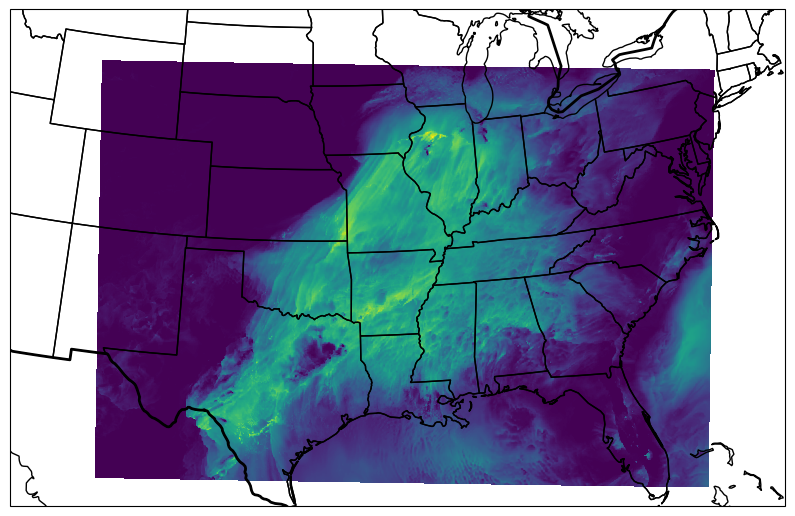

In [32]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=ccrs.LambertConformal())

#ax.stock_img()

ax.add_feature(cfeature.COASTLINE)

ax.add_feature(cfeature.BORDERS, linewidth=2)
ax.add_feature(cfeature.STATES)
ax.pcolormesh(ds_final.longitude, ds_final.latitude, ds_final.cape.isel(valid_time=11), transform = ccrs.PlateCarree())
ax.set_extent([-110, -75, 25, 45])

In [33]:
import pandas as pd

In [7]:
#5 hour rolling products
refc_5hr_rolling = ds_final["refc"].rolling(valid_time=5).max()
cape_5hr_rolling = ds_final["cape"].rolling(valid_time=5).max()
wz_5hr_rolling = ds_final["wz"].rolling(valid_time=5).max()
veril_5hr_rolling = ds_final["veril"].rolling(valid_time=5).max()
#derived products
vil_density =  (ds_final["veril"] /  ds_final["cloudtop"]) 
vil_density_5hr_rolling = vil_density.rolling(valid_time=5).max()

NameError: name 'ds_final' is not defined

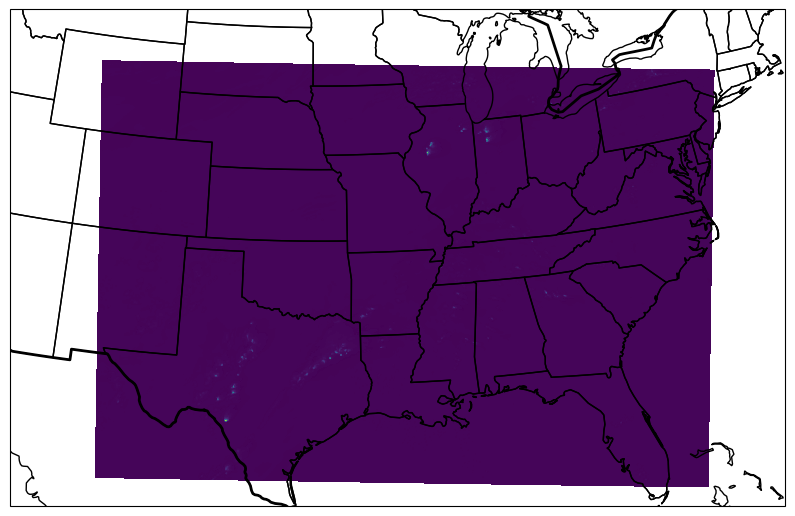

In [35]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=ccrs.LambertConformal())

#ax.stock_img()

ax.add_feature(cfeature.COASTLINE)

ax.add_feature(cfeature.BORDERS, linewidth=2)
ax.add_feature(cfeature.STATES)
ax.pcolormesh(ds_final.longitude, ds_final.latitude, vil_density.isel(valid_time=11), transform = ccrs.PlateCarree())
ax.set_extent([-110, -75, 25, 45])

In [1]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=ccrs.LambertConformal())

#ax.stock_img()

ax.add_feature(cfeature.COASTLINE)

ax.add_feature(cfeature.BORDERS, linewidth=2)
ax.add_feature(cfeature.STATES)
ax.pcolormesh(ds_final.longitude, ds_final.latitude, vil_density_5hr_rolling.isel(valid_time=15), transform = ccrs.PlateCarree(), cmap='twilight' )
ax.set_extent([-110, -75, 25, 45])

NameError: name 'plt' is not defined

In [6]:
import cartopy.feature as cfeature
def map(): #map function used to create our base maps when needed
    fig = plt.figure(figsize=(12,9)) #figure size for us to place our base map
    ax = fig.add_subplot(111, projection=ccrs.LambertConformal()) #projection used for our base map
    ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
    ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.add_feature(cfeature.BORDERS)
    return fig, ax

In [1]:
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(ds_final.longitude, ds_final.latitude, vil_density_5hr_rolling.isel(valid_time=15), cmap = 'rainbow', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of rainbow and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'CAPE (Kg/m^-2)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size

plt.show() #plotting our map

TypeError: map() must have at least two arguments.

In [3]:
ds_file = xr.open_dataset("hrrr_2026031012.nc") # ds_file used to open the netcdf file for us to use the data to create plots
ds_file


sh: 1: getfattr: not found


<xarray.Dataset> Size: 615MB
Dimensions:                  (valid_time: 49, y: 650, x: 950)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-03-10T12:0...
    time                     datetime64[ns] 8B ...
    step                     (valid_time) timedelta64[ns] 392B ...
    atmosphere               float64 8B ...
    latitude                 (y, x) float64 5MB ...
    longitude                (y, x) float64 5MB ...
    cloudTop                 float64 8B ...
    sigmaLayer               float64 8B ...
    pressureFromGroundLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 121MB ...
    unknown                  (valid_time, y, x) float32 121MB ...
    veril                    (valid_time, y, x) float32 121MB ...
    wz                       (valid_time, y, x) float32 121MB ...
    cape                     (valid_time, y, x) float32 121MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-25T15:42 GRIB to CDM+CF via cfgrib-0.9.1...

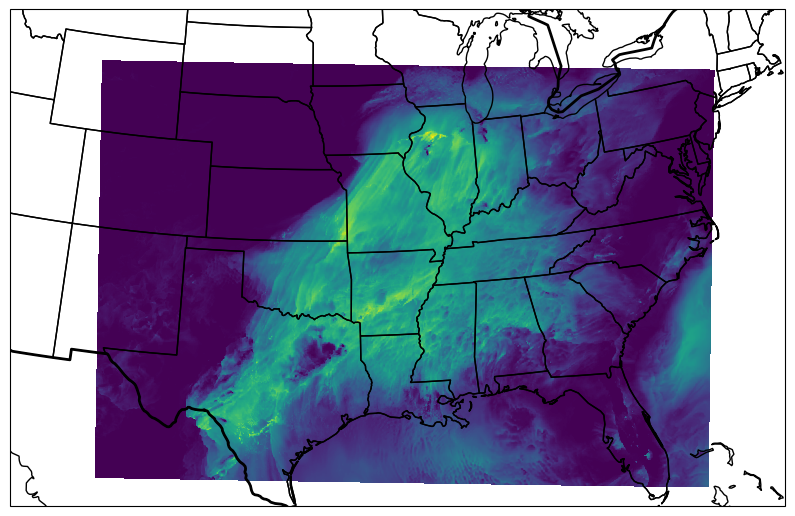

In [9]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=ccrs.LambertConformal())

#ax.stock_img()

ax.add_feature(cfeature.COASTLINE)

ax.add_feature(cfeature.BORDERS, linewidth=2)
ax.add_feature(cfeature.STATES)
ax.pcolormesh(ds_file.longitude, ds_file.latitude, ds_file.cape.isel(valid_time=11), transform = ccrs.PlateCarree())
ax.set_extent([-110, -75, 25, 45])

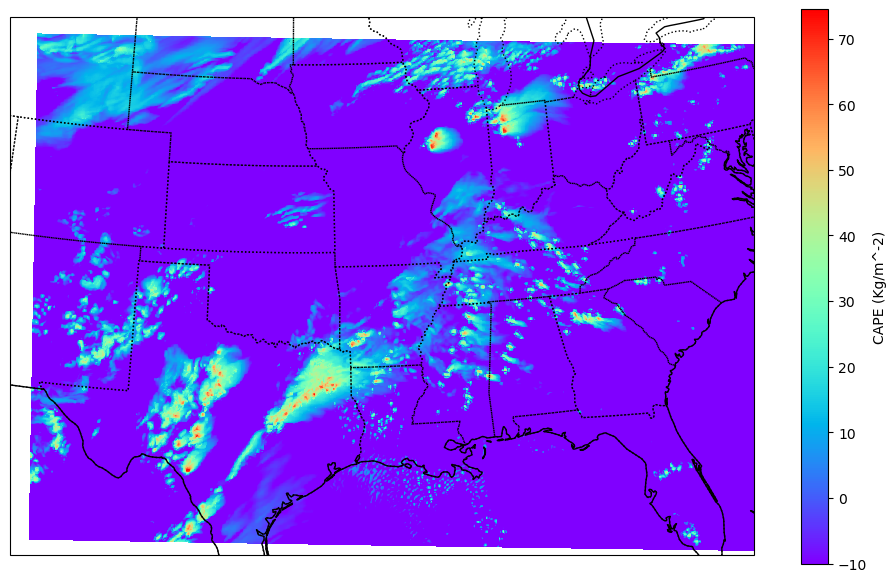

In [12]:
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(ds_file.longitude, ds_file.latitude, ds_file.refc.isel(valid_time=11), cmap = 'rainbow', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of rainbow and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'CAPE (Kg/m^-2)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size

plt.show() #plotting our map

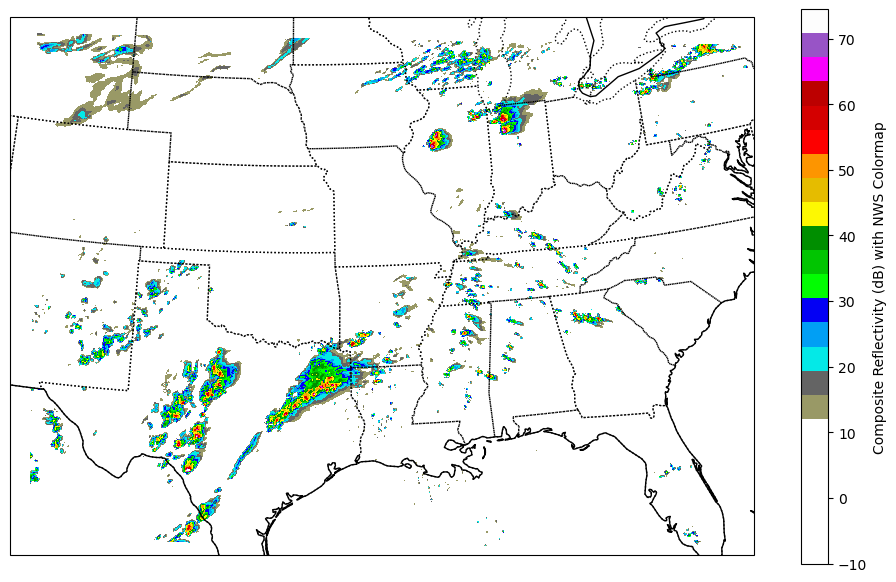

In [17]:
# Custom Colormap of Composite Reflectivity worked on by Jonathan
from matplotlib.colors import ListedColormap #Importing module to use to generate custom colormap

# Colormap found on notebook.community, using the NWS's color scheme for composite reflectivity
nws_reflectivity_colors = [ 
    "#FFFFFF", # ND
    "#FFFFFF", # -30
    "#FFFFFF", # -25
    "#FFFFFF", # -20
    "#FFFFFF", # -15
    "#FFFFFF", # -10
    "#999966", # -5
    "#646464", # 0
    "#04e9e7", # 5
    "#019ff4", # 10
    "#0300f4", # 15
    "#02fd02", # 20
    "#01c501", # 25
    "#008e00", # 30
    "#fdf802", # 35
    "#e5bc00", # 40
    "#fd9500", # 45
    "#fd0000", # 50
    "#d40000", # 55
    "#bc0000", # 60
    "#f800fd", # 65
    "#9854c6", # 70
    "#fdfdfd" # 75
    ]

# Converting the colormap to a usable object to plot
nws_cmap = ListedColormap(nws_reflectivity_colors, name='nws_reflectivity_colors')

fig,ax=map() # Calling and printing the base map function created above

# Creating a colormesh plot of 5-hour max composite reflectivity liquid plotted on longitude and latitude, valid at 03Z, using the custom colormap
custom_colormap = ax.pcolormesh(ds_file.longitude, ds_file.latitude, ds_file.refc.isel(valid_time=11), cmap = nws_cmap, transform = ccrs.PlateCarree()) 
# Creating a vertically oriented colorbar of 5-hour max composite reflectivity, using the custom colormap
plt.colorbar(custom_colormap, ax=ax, label = 'Composite Reflectivity (dB) with NWS Colormap', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
# Creating title containing information about content, initial time, and valid time of the plot

plt.show() # Display the map

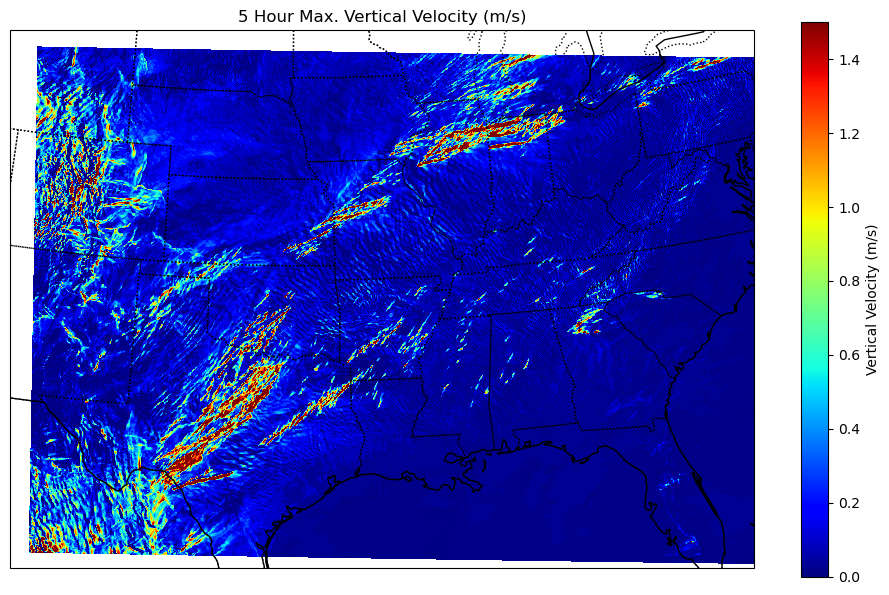

In [19]:
#Plot 2: Vertical Velocity worked on by Jonathan

wz_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max() #Extracting the 5-hour max vertical velocity from the data file so it can be plotted

fig,ax=map() # Calling and printing the base map function created above

# Creating a colormesh plot of 5-hour max vertical velocity plotted on longitude and latitude, valid at 03Z
vert_velocity = ax.pcolormesh(ds_file.longitude, ds_file.latitude, wz_5hr_rolling.isel(valid_time=15), cmap = 'jet', vmin = 0, vmax = 1.5, transform=ccrs.PlateCarree())

cbar = plt.colorbar(vert_velocity, ax=ax, orientation='vertical', pad=0.05, shrink=0.8) # Creating a vertically oriented colorbar of 5-hour max vertical velocity
cbar.set_label('Vertical Velocity (m/s)') # Labeling colorbar with title and units

# Creating title containing information about content, initial time, and valid time of the plot
plt.title(f'5 Hour Max. Vertical Velocity (m/s)')

plt.show() # Display the map

In [2]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
ds_file = xr.open_dataset("hrrr_2026031012.nc") # ds_file used to open the netcdf file for us to use the data to create plots
ds_file = ds_file.rename({"unknown":"cloudtop"})
ds_file

sh: 1: getfattr: not found


<xarray.Dataset> Size: 615MB
Dimensions:                  (valid_time: 49, y: 650, x: 950)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-03-10T12:0...
    time                     datetime64[ns] 8B ...
    step                     (valid_time) timedelta64[ns] 392B ...
    atmosphere               float64 8B ...
    latitude                 (y, x) float64 5MB ...
    longitude                (y, x) float64 5MB ...
    cloudTop                 float64 8B ...
    sigmaLayer               float64 8B ...
    pressureFromGroundLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 121MB ...
    cloudtop                 (valid_time, y, x) float32 121MB ...
    veril                    (valid_time, y, x) float32 121MB ...
    wz                       (valid_time, y, x) float32 121MB ...
    cape                     (valid_time, y, x) float32 121MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T21:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
#5 hour rolling products
refc_5hr_rolling = ds_file["refc"].rolling(valid_time=5).max()
cape_5hr_rolling = ds_file["cape"].rolling(valid_time=5).max()
wz_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max()
veril_5hr_rolling = ds_file["veril"].rolling(valid_time=5).max()
#derived products
vil_density =  (ds_file["veril"] /  ds_file["cloudtop"]) *100
vil_density_5hr_rolling = vil_density.rolling(valid_time=5).max()

In [4]:
import cartopy.feature as cfeature
def map(): #map function used to create our base maps when needed
    fig = plt.figure(figsize=(12,9)) #figure size for us to place our base map
    ax = fig.add_subplot(111, projection=ccrs.LambertConformal()) #projection used for our base map
    ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
    ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.add_feature(cfeature.BORDERS)
    return fig, ax
lon = ds_file['longitude'] #getting the longitude from our ds_file so we can plot our data
lat = ds_file['latitude'] #gettting the latitude from our ds_file so we can plot our data
dataproj = ccrs.PlateCarree() #making PlateCarree in our dataproj so we can add it to our pcolormesh

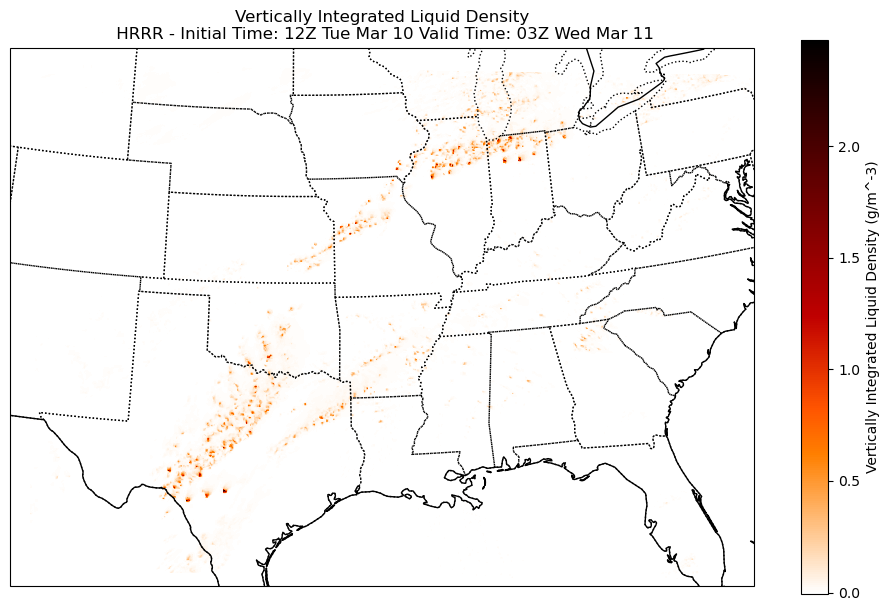

In [5]:


fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_5hr_rolling.isel(valid_time=15), cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'Vertically Integrated Liquid Density (g/m^-3)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"Vertically Integrated Liquid Density\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() # Display the map

In [6]:
import metpy.calc as mpcalc

# Start with all contributions set to 0
vil_density_5hr_rolling_time =vil_density_5hr_rolling.isel(valid_time=15).values
vil_density_contribution = np.zeros_like(vil_density_5hr_rolling_time)


mask = (vil_density_5hr_rolling_time >= 0.25) & (vil_density_5hr_rolling_time < 1.75 )
vil_density_contribution[mask] = (vil_density_5hr_rolling_time[mask] - 0.25) / 1.50




mask = (vil_density_5hr_rolling_time >= 1.75) 
vil_density_contribution[mask] = 1.0




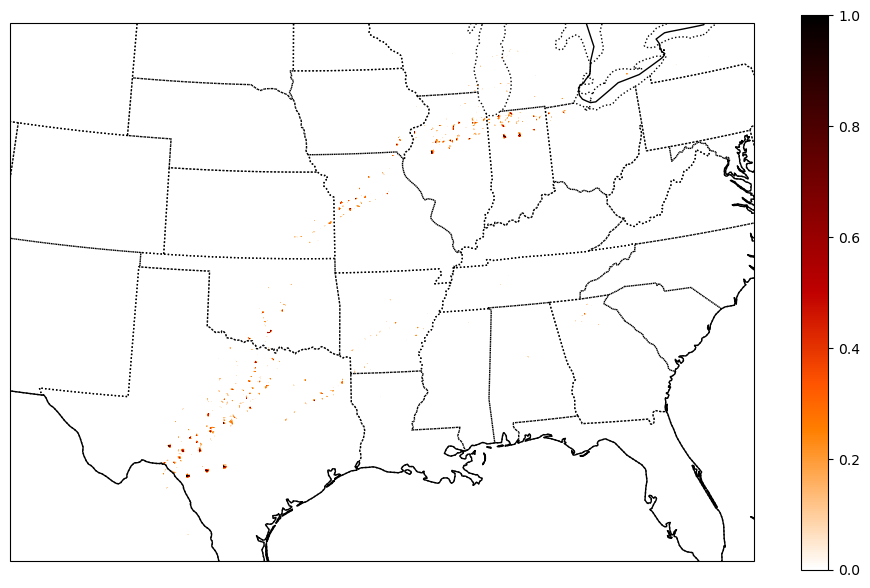

In [7]:
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_contribution, cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, shrink = 0.8)


In [46]:
vil_density_contribution

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(650, 950), dtype=float32)

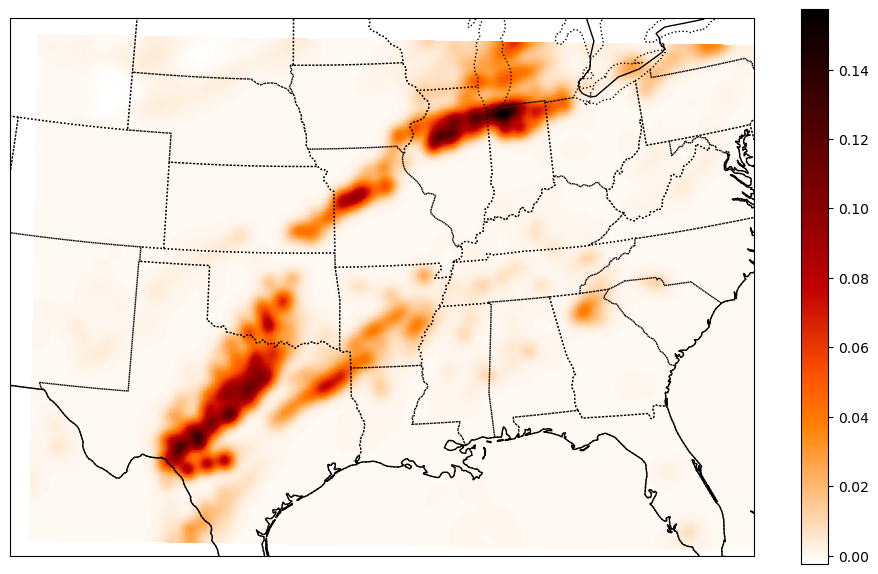

In [55]:
import metpy.calc as mpcalc
vil_density_5hr_rolling_time_smooth = mpcalc.smooth_gaussian(vil_density_5hr_rolling_time, 50)

fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_5hr_rolling_time_smooth, cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, shrink = 0.8)

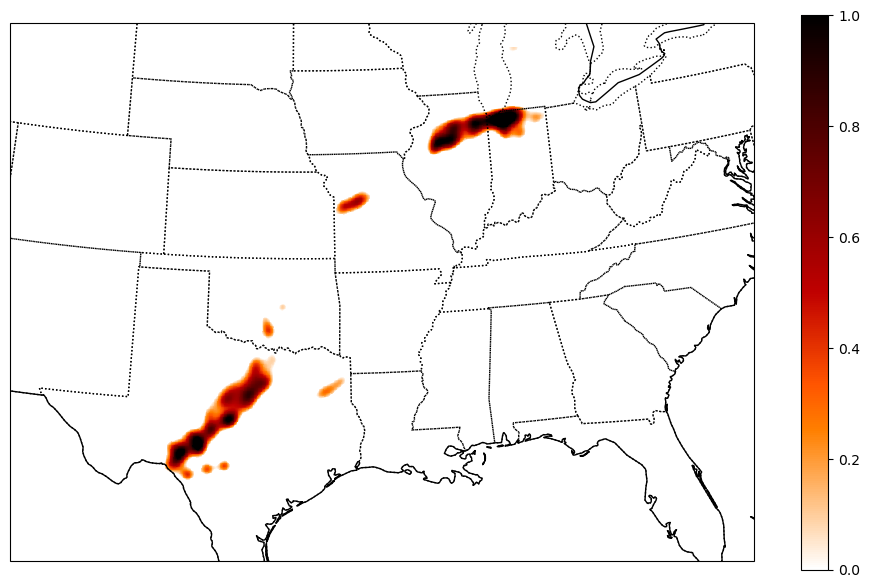

In [58]:
vil_density_contribution_smooth = np.zeros_like(vil_density_5hr_rolling_time_smooth)


mask = (vil_density_5hr_rolling_time_smooth >= 0.06) & (vil_density_5hr_rolling_time_smooth < 0.12 )
vil_density_contribution_smooth[mask] = (vil_density_5hr_rolling_time_smooth[mask] - 0.06) / 0.06




mask = (vil_density_5hr_rolling_time_smooth >= 0.12) 
vil_density_contribution_smooth[mask] = 1.0


fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_contribution_smooth, cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, shrink = 0.8)
